# Classifier-free guidance

One net, two predictions, an amplified difference:

    eps = eps_∅ + w · (eps_y - eps_∅)

`w=1` is the plain conditional model, `w=0` the unconditional one, and `w>1`
pushes further along the label's direction than the model itself believes. That
does not sample `p(x|y)` — it samples a sharpened `p(x)·p(y|x)^w`, so obedience
and diversity trade against each other by construction.

Obedience needs a judge, so the setup cell trains a small CNN on MNIST to say
what each sample looks like. Diversity is across-sample pixel std within a class.

**Run the setup cell once, then the sweep.**


## Setup


In [ ]:
# --- setup: checkpoint, sampler, and a CNN to judge the samples. Run once. ---
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from cfg import Guided
from ddim import DDIMSampler
from forward_process import ForwardProcess
from unet import UNet
from utils import repo_root

dev = "cuda" if torch.cuda.is_available() else "cpu"

# a run trained with --label-dropout > 0; without it the null row never learned
# anything and w != 1 is meaningless
RUN = "cfg_2026-09-09_18-17-27"
ART = repo_root() / "artifacts"

ck = torch.load(ART / RUN / "ckpt.pt", map_location=dev)
C = ck["num_classes"]
net = UNet(num_classes=C).to(dev)
net.load_state_dict(ck["ema"])  # the averaged weights are the ones that ship
net.eval()
fp = ForwardProcess().to(dev)
fp.load_state_dict(ck["fp"])  # schedule buffers come from the checkpoint
smp = DDIMSampler(fp, steps=50).to(dev)

_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
ds = datasets.MNIST(root=repo_root() / "data", train=True, transform=_tf)
ds_test = datasets.MNIST(root=repo_root() / "data", train=False, transform=_tf)

# the judge. Small and quick -- it only has to be much better than the thing it
# is grading, and its own errors are a floor under every accuracy below.
clf = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(dev)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
torch.manual_seed(0)
for _ in range(2):
    for xb, yb in DataLoader(ds, batch_size=256, shuffle=True, num_workers=4):
        loss = F.cross_entropy(clf(xb.to(dev)), yb.to(dev))
        opt.zero_grad()
        loss.backward()
        opt.step()
clf.eval()

with torch.no_grad():
    judge_acc = sum(
        (clf(xb.to(dev)).argmax(1) == yb.to(dev)).sum().item()
        for xb, yb in DataLoader(ds_test, batch_size=1000)
    ) / len(ds_test)

PER = 20  # samples per class
y_all = torch.arange(C, device=dev).repeat_interleave(PER)


@torch.no_grad()
def sample_at(w, seed=7):
    """PER images of every class at guidance w. Same seed every time, so all
    the w below share one x_T and the only variable is the guidance."""
    torch.manual_seed(seed)
    return smp.sample(Guided(net, y_all, w), (y_all.shape[0], 1, 28, 28), dev)


@torch.no_grad()
def score(x):
    """(does the judge agree with the label, spread within a class, pinned pixels)"""
    acc = (clf(x).argmax(1) == y_all).float().mean().item()
    div = x.view(C, PER, -1).std(1).mean().item()
    sat = (x.abs() > 0.99).float().mean().item()
    return acc, div, sat


def show(x, nrow, title=""):
    g = make_grid(x.cpu(), nrow=nrow, normalize=True, value_range=(-1, 1), padding=2)
    plt.figure(figsize=(nrow * 0.42, x.shape[0] / nrow * 0.42))
    plt.imshow(g.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title, fontsize=9)
    plt.show()


print(f"{RUN}  classes {C}   judge test accuracy {judge_acc:.4f}   [{dev}]")

cfg_2026-09-09_18-17-27  classes 10   judge test accuracy 0.9835   [cuda]


## Sweeping w


    w  accuracy  diversity   pinned
  0.0     0.065     0.3631    0.499
  1.0     0.950     0.3091    0.510
  1.5     0.990     0.2948    0.519
  2.0     0.995     0.2876    0.513
  3.0     1.000     0.2798    0.480
  5.0     1.000     0.2768    0.381
  8.0     1.000     0.2789    0.239
 15.0     1.000     0.2966    0.115


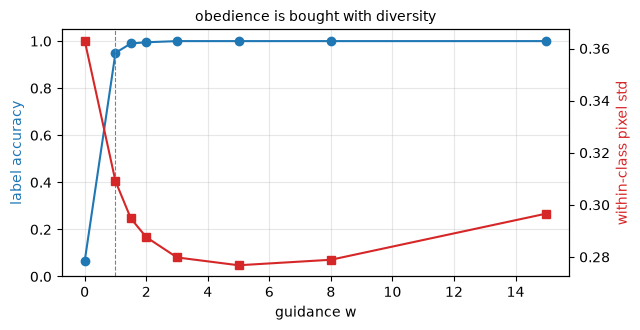

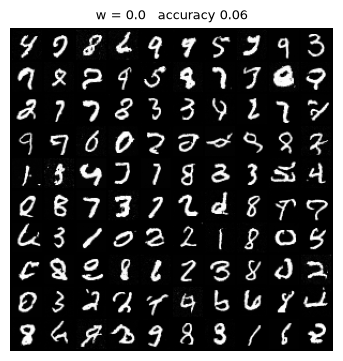

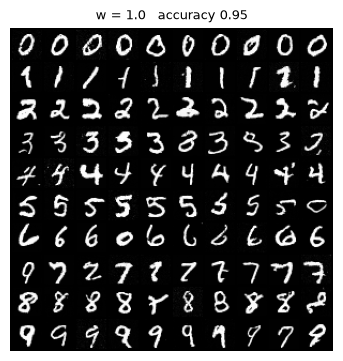

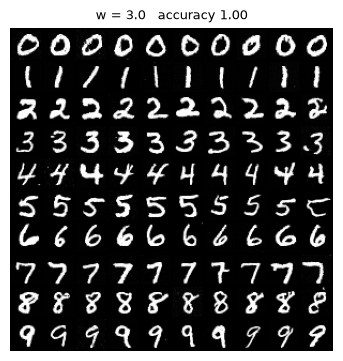

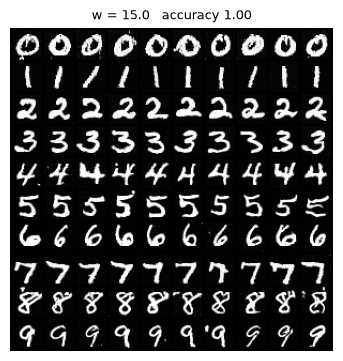

In [2]:
# --- the sweep: obedience up, diversity down ---
WS = [0.0, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 15.0]
xs = {w: sample_at(w) for w in WS}
acc, div, sat = zip(*(score(xs[w]) for w in WS))

print(f"{'w':>5} {'accuracy':>9} {'diversity':>10} {'pinned':>8}")
for i, w in enumerate(WS):
    print(f"{w:5.1f} {acc[i]:9.3f} {div[i]:10.4f} {sat[i]:8.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(WS, acc, marker="o", color="tab:blue", label="label accuracy")
ax.set_xlabel("guidance w")
ax.set_ylabel("label accuracy", color="tab:blue")
ax.set_ylim(0, 1.05)
ax.axvline(1.0, ls="--", lw=0.8, color="grey")  # w=1 is the plain conditional net
ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(WS, div, marker="s", color="tab:red", label="diversity")
ax2.set_ylabel("within-class pixel std", color="tab:red")
ax.set_title("obedience is bought with diversity", fontsize=10)
plt.tight_layout()
plt.show()

# the numbers alone would call w=15 as diverse as w=2. It is not: past w≈8 the
# strokes erode into speckled outlines, and speckle is pixel variance too.
for w in (0.0, 1.0, 3.0, 15.0):
    show(xs[w][::2], C, f"w = {w}   accuracy {score(xs[w])[0]:.2f}")